# Daily Challenge — Text Analysis of Books using Word Cloud

**Week 7 · Day 1 — Natural Language Processing**

In this challenge we analyse three Lewis Carroll books from Project Gutenberg:

1. *Alice's Adventures in Wonderland*
2. *Through the Looking-Glass and What Alice Found There*
3. *A Tangled Tale*

We will cover the full NLP preprocessing pipeline (cleaning, tokenization,
stop-word removal, stemming, lemmatization, POS tagging, NER) and then analyse
the texts with **Word Clouds**, the **Bag-of-Words (BoW)** model and **TF-IDF**.

> **Environment** — this notebook runs in a dedicated NLP virtual environment
> (`Week7/env`). Select the kernel **Python (NLP env)** before running.


In [1]:
# --- Imports -------------------------------------------------------------
import re          # regular expressions, used to clean non-word characters
import requests    # to download the book texts over HTTP

# NLTK: the classic, rule-based NLP toolkit we use for tokenizing, stop words,
# stemming, POS tagging and named-entity recognition.
import nltk
from nltk.tokenize import word_tokenize   # split raw text into word tokens
from nltk.corpus import stopwords         # list of common "filler" words
from nltk.stem import PorterStemmer        # rule-based suffix stripper (stemmer)
from nltk import pos_tag, ne_chunk         # part-of-speech tagger + entity chunker

# spaCy: a modern NLP library with pre-trained models; we use it for lemmatization.
import spacy

# Visualisation + feature-extraction tools.
import matplotlib.pyplot as plt                                   # plots
from wordcloud import WordCloud                                   # word clouds
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer  # BoW / TF-IDF

# Download the NLTK data packages this notebook needs. They are already present
# in the env, so calling download() again simply verifies them (no-op).
for pkg in ['punkt', 'punkt_tab', 'stopwords',
            'averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng',
            'maxent_ne_chunker', 'maxent_ne_chunker_tab', 'words']:
    nltk.download(pkg, quiet=True)

# Load spaCy's small English pipeline once and reuse it (used only for lemmas).
nlp = spacy.load('en_core_web_sm')

# Render matplotlib figures inline inside the notebook.
%matplotlib inline
print("Setup complete.")


Setup complete.


## Text preprocessing

### 1. `load_texts()` — download and clean the corpus

The function receives a list of URLs, downloads each one with `requests`,
removes non-word characters with a regular expression (keeping letters and
whitespace so that the ` START` / ` END` markers survive for the next step),
and appends the cleaned text to the corpus that is returned.

In [2]:
URLS = [
    "https://www.gutenberg.org/cache/epub/11/pg11.txt",      # Alice's Adventures in Wonderland
    "https://www.gutenberg.org/cache/epub/12/pg12.txt",      # Through the Looking-Glass
    "https://www.gutenberg.org/cache/epub/29042/pg29042.txt" # A Tangled Tale
]
TITLES = [
    "Alice's Adventures in Wonderland",
    "Through the Looking-Glass",
    "A Tangled Tale",
]


def load_texts(urls):
    """Download each URL, clean non-word characters and return the corpus."""
    corpus = []                       # will hold one cleaned string per book
    for url in urls:
        # Download the file; the User-Agent header avoids Gutenberg blocking us.
        response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
        response.raise_for_status()   # raise an error if the download failed
        text = response.text          # the raw text of the book

        # Remove every character that is NOT a letter or whitespace.
        # Digits and punctuation become spaces, while words — and the
        # " START"/" END" markers we need in the next step — are kept.
        cleaned = re.sub(r"[^A-Za-z\s]", " ", text)
        # Collapse any run of whitespace (spaces, newlines, tabs) into one space.
        cleaned = re.sub(r"\s+", " ", cleaned).strip()

        corpus.append(cleaned)        # add the cleaned text to the corpus
    return corpus


# Build the corpus by downloading + cleaning all three books.
corpus = load_texts(URLS)
print(f"Loaded {len(corpus)} texts.")
for title, text in zip(TITLES, corpus):
    print(f"  - {title}: {len(text):,} characters")


Loaded 3 texts.
  - Alice's Adventures in Wonderland: 153,874 characters
  - Through the Looking-Glass: 170,928 characters
  - A Tangled Tale: 162,540 characters


### 2. First 200 characters of each text — and removing the irrelevant parts

In [3]:
# Print the first 200 characters of each book to inspect what we downloaded.
for title, text in zip(TITLES, corpus):
    print(f"=== {title} ===")
    print(text[:200])   # slice the first 200 characters
    print()


=== Alice's Adventures in Wonderland ===
The Project Gutenberg eBook of Alice s Adventures in Wonderland This eBook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no restri

=== Through the Looking-Glass ===
The Project Gutenberg eBook of Through the Looking Glass This eBook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no restrictions 

=== A Tangled Tale ===
The Project Gutenberg eBook of A Tangled Tale This eBook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no restrictions whatsoever 



Yes — the first 200 characters are **not relevant** to the analysis.
Every Project Gutenberg file starts with a long header (title, author,
licensing notice, credits) and ends with the full Gutenberg license. These
boilerplate sections would pollute our word frequencies, so we cut them out.

Following the hint, we slice each text between the ` START` and ` END`
markers that Gutenberg places around the actual book content.

In [4]:
def strip_gutenberg(text):
    """Keep only the content between the Gutenberg START and END markers."""
    start = text.find(" START")   # index where the real book begins
    end = text.find(" END")       # index where the real book ends
    # find() returns -1 when a marker is missing; only slice if both were found.
    if start != -1 and end != -1:
        return text[start:end]    # keep just the story, drop the boilerplate
    return text                   # fallback: return the text unchanged


# Apply the stripping to every book in the corpus.
books = [strip_gutenberg(t) for t in corpus]

# Show how many characters survived (much smaller than the raw downloads).
for title, book in zip(TITLES, books):
    print(f"{title}: {len(book):,} characters after stripping boilerplate")


Alice's Adventures in Wonderland: 135,575 characters after stripping boilerplate
Through the Looking-Glass: 152,670 characters after stripping boilerplate
A Tangled Tale: 142,282 characters after stripping boilerplate


### 3. Tokenize the text — first 150 tokens of each book

In [5]:
# Tokenize each book: split the text into a list of individual word tokens.
book_tokens = [word_tokenize(book) for book in books]

# Print the first 150 tokens of each book.
for title, tokens in zip(TITLES, book_tokens):
    print(f"=== {title} ({len(tokens):,} tokens) ===")
    print(tokens[:150])   # the first 150 tokens
    print()


=== Alice's Adventures in Wonderland (27,438 tokens) ===
['START', 'OF', 'THE', 'PROJECT', 'GUTENBERG', 'EBOOK', 'ALICE', 'S', 'ADVENTURES', 'IN', 'WONDERLAND', 'Illustration', 'Alice', 's', 'Adventures', 'in', 'Wonderland', 'by', 'Lewis', 'Carroll', 'THE', 'MILLENNIUM', 'FULCRUM', 'EDITION', 'Contents', 'CHAPTER', 'I', 'Down', 'the', 'Rabbit', 'Hole', 'CHAPTER', 'II', 'The', 'Pool', 'of', 'Tears', 'CHAPTER', 'III', 'A', 'Caucus', 'Race', 'and', 'a', 'Long', 'Tale', 'CHAPTER', 'IV', 'The', 'Rabbit', 'Sends', 'in', 'a', 'Little', 'Bill', 'CHAPTER', 'V', 'Advice', 'from', 'a', 'Caterpillar', 'CHAPTER', 'VI', 'Pig', 'and', 'Pepper', 'CHAPTER', 'VII', 'A', 'Mad', 'Tea', 'Party', 'CHAPTER', 'VIII', 'The', 'Queen', 's', 'Croquet', 'Ground', 'CHAPTER', 'IX', 'The', 'Mock', 'Turtle', 's', 'Story', 'CHAPTER', 'X', 'The', 'Lobster', 'Quadrille', 'CHAPTER', 'XI', 'Who', 'Stole', 'the', 'Tarts', 'CHAPTER', 'XII', 'Alice', 's', 'Evidence', 'CHAPTER', 'I', 'Down', 'the', 'Rabbit', 'Hole', 'Alice', '

### 4. Remove stop words (NLTK)

Stop words (`i`, `me`, `my`, `the`, `and`, ...) carry little meaning, so we drop
them. We compare a stop word with `count()` before and after to confirm removal.

In [6]:
# Build a set of English stop words for fast membership testing.
stop_words = set(stopwords.words("english"))

# For each book, keep only the tokens that are NOT stop words.
tokens_nostop = []
for tokens in book_tokens:
    # Compare in lower case so "The" and "the" are both treated as stop words.
    filtered = [w for w in tokens if w.lower() not in stop_words]
    tokens_nostop.append(filtered)

# Verify removal with count(): each of these stop words should now be 0.
check_words = ["i", "me", "my", "myself", "we", "our", "ours", "ourselves"]
for title, before, after in zip(TITLES, book_tokens, tokens_nostop):
    before_l = [w.lower() for w in before]   # tokens before removal (lower-cased)
    after_l = [w.lower() for w in after]     # tokens after removal (lower-cased)
    print(f"=== {title} ===")
    for w in check_words:
        # count() of each stop word before vs. after filtering.
        print(f"  '{w}': before={before_l.count(w):4d}  after={after_l.count(w)}")
    print(f"  tokens: {len(before):,} -> {len(after):,}")   # total shrinks a lot
    print()


=== Alice's Adventures in Wonderland ===
  'i': before= 546  after=0
  'me': before=  68  after=0
  'my': before=  58  after=0
  'myself': before=   7  after=0
  'we': before=  34  after=0
  'our': before=   8  after=0
  'ours': before=   1  after=0
  'ourselves': before=   1  after=0
  tokens: 27,438 -> 12,310

=== Through the Looking-Glass ===
  'i': before= 662  after=0
  'me': before=  96  after=0
  'my': before=  77  after=0
  'myself': before=   7  after=0
  'we': before=  54  after=0
  'our': before=  12  after=0
  'ours': before=   0  after=0
  'ourselves': before=   0  after=0
  tokens: 31,105 -> 14,113

=== A Tangled Tale ===
  'i': before= 395  after=0
  'me': before=  53  after=0
  'my': before=  75  after=0
  'myself': before=   4  after=0
  'we': before= 124  after=0
  'our': before=  27  after=0
  'ours': before=   0  after=0
  'ourselves': before=   1  after=0
  tokens: 27,518 -> 13,854



### 5. Stemming with `PorterStemmer()` — first 50 stemmed tokens

In [7]:
# Create one Porter stemmer and reuse it for every token.
stemmer = PorterStemmer()

# Stem the stop-word-free tokens of each book.
book_stems = []
for tokens in tokens_nostop:
    # stem() chops common suffixes off each word (e.g. "running" -> "run").
    stems = [stemmer.stem(w) for w in tokens]
    book_stems.append(stems)

# Print the first 50 stemmed tokens of each book.
for title, stems in zip(TITLES, book_stems):
    print(f"=== {title} ===")
    print(stems[:50])
    print()


=== Alice's Adventures in Wonderland ===
['start', 'project', 'gutenberg', 'ebook', 'alic', 'adventur', 'wonderland', 'illustr', 'alic', 'adventur', 'wonderland', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', 'content', 'chapter', 'rabbit', 'hole', 'chapter', 'ii', 'pool', 'tear', 'chapter', 'iii', 'caucu', 'race', 'long', 'tale', 'chapter', 'iv', 'rabbit', 'send', 'littl', 'bill', 'chapter', 'v', 'advic', 'caterpillar', 'chapter', 'vi', 'pig', 'pepper', 'chapter', 'vii', 'mad', 'tea', 'parti', 'chapter']

=== Through the Looking-Glass ===
['start', 'project', 'gutenberg', 'ebook', 'look', 'glass', 'illustr', 'look', 'glass', 'alic', 'found', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', 'dramati', 'person', 'arrang', 'commenc', 'game', 'white', 'red', 'piec', 'pawn', 'pawn', 'piec', 'tweedlede', 'daisi', 'daisi', 'humpti', 'dumpti', 'unicorn', 'haigha', 'messeng', 'carpent', 'sheep', 'oyster', 'oyster', 'walru', 'w', 'queen', 'lili', 'tiger', 'lili', 'r', 'queen', 'w', 'king

### 6. Lemmatization with spaCy (`en_core_web_sm`) — first 50 lemmatized tokens

In spaCy the lemma is available on each token as the `.lemma_` attribute.

In [8]:
# Lemmatize each book with spaCy and keep only meaningful words.
book_lemmas = []
for book in books:
    doc = nlp(book)   # run the spaCy pipeline; `doc` is a sequence of tokens
    # token.lemma_ is the dictionary base form; keep alphabetic, non-stop words.
    lemmas = [token.lemma_.lower() for token in doc
              if token.is_alpha and not token.is_stop]
    book_lemmas.append(lemmas)

# Print the first 50 lemmatized tokens of each book.
for title, lemmas in zip(TITLES, book_lemmas):
    print(f"=== {title} ===")
    print(lemmas[:50])
    print()


=== Alice's Adventures in Wonderland ===
['start', 'project', 'gutenberg', 'ebook', 'alice', 's', 'adventures', 'wonderland', 'illustration', 'alice', 's', 'adventures', 'wonderland', 'lewis', 'carroll', 'millennium', 'fulcrum', 'edition', 'content', 'chapter', 'rabbit', 'hole', 'chapter', 'ii', 'pool', 'tears', 'chapter', 'iii', 'caucus', 'race', 'long', 'tale', 'chapter', 'iv', 'rabbit', 'send', 'little', 'bill', 'chapter', 'v', 'advice', 'caterpillar', 'chapter', 'vi', 'pig', 'pepper', 'chapter', 'vii', 'mad', 'tea']

=== Through the Looking-Glass ===
['start', 'project', 'gutenberg', 'ebook', 'looking', 'glass', 'illustration', 'looking', 'glass', 'alice', 'find', 'lewis', 'carroll', 'millennium', 'fulcrum', 'edition', 'dramatis', 'person', 'arrange', 'commencement', 'game', 'white', 'red', 'piece', 'pawns', 'pawns', 'pieces', 'tweedledee', 'daisy', 'daisy', 'humpty', 'dumpty', 'unicorn', 'haigha', 'messenger', 'carpenter', 'sheep', 'oyster', 'oyster', 'walrus', 'w', 'queen', 'lily

### 7. Stemmed vs. lemmatized — what is different and why?

**Stemming** (Porter) is a crude, rule-based chopping of suffixes. It is fast
but the result is often **not a real word**:

| original | Porter stem | spaCy lemma |
|----------|-------------|-------------|
| beginning | `begin` | begin |
| adventures | `adventur` | adventure |
| happily | `happili` | happily |
| says / said | `say` / `said` | say / say |

**Lemmatization** uses a dictionary and the part-of-speech of each word to map
it to its true base form (the *lemma*), so the output is always a valid word
(`adventures -> adventure`, `said -> say`, `better -> good`).

**In short:** stemming is faster but produces non-words and can over-/under-cut
suffixes; lemmatization is slower (it needs linguistic knowledge) but yields
clean, dictionary-valid words — which is why we use the **lemmatized** text for
the word clouds and frequency analysis below.

### 8. POS tagging with NLTK

In [9]:
# pos_tag returns (word, tag) pairs, e.g. ("Alice", "NNP") = proper noun.
# We tag a sample of each book (the first 30 tokens) so the output stays readable.
for title, tokens in zip(TITLES, book_tokens):
    tagged = pos_tag(tokens[:30])   # attach a part-of-speech tag to each token
    print(f"=== {title} — POS tags (first 30 tokens) ===")
    print(tagged)
    print()


=== Alice's Adventures in Wonderland — POS tags (first 30 tokens) ===
[('START', 'NNP'), ('OF', 'IN'), ('THE', 'NNP'), ('PROJECT', 'NNP'), ('GUTENBERG', 'NNP'), ('EBOOK', 'NNP'), ('ALICE', 'NNP'), ('S', 'NNP'), ('ADVENTURES', 'NNP'), ('IN', 'NNP'), ('WONDERLAND', 'NNP'), ('Illustration', 'NNP'), ('Alice', 'NNP'), ('s', 'NN'), ('Adventures', 'NNP'), ('in', 'IN'), ('Wonderland', 'NNP'), ('by', 'IN'), ('Lewis', 'NNP'), ('Carroll', 'NNP'), ('THE', 'NNP'), ('MILLENNIUM', 'NNP'), ('FULCRUM', 'NNP'), ('EDITION', 'NNP'), ('Contents', 'NNP'), ('CHAPTER', 'NN'), ('I', 'PRP'), ('Down', 'RP'), ('the', 'DT'), ('Rabbit', 'NN')]

=== Through the Looking-Glass — POS tags (first 30 tokens) ===
[('START', 'NNP'), ('OF', 'IN'), ('THE', 'NNP'), ('PROJECT', 'NNP'), ('GUTENBERG', 'NNP'), ('EBOOK', 'NNP'), ('THROUGH', 'IN'), ('THE', 'NNP'), ('LOOKING', 'NNP'), ('GLASS', 'NNP'), ('Illustration', 'NNP'), ('THROUGH', 'IN'), ('THE', 'NNP'), ('LOOKING', 'NNP'), ('GLASS', 'NNP'), ('And', 'CC'), ('What', 'WP'), ('A

### 9. Named Entity Recognition with NLTK

In [10]:
def extract_entities(tokens):
    """Return (entity_text, entity_label) pairs found by NLTK's ne_chunk."""
    # ne_chunk needs POS tags first, then groups entity words into subtrees.
    tree = ne_chunk(pos_tag(tokens))
    entities = []
    for subtree in tree:
        # Real entities are subtrees with a .label() (e.g. PERSON, GPE);
        # plain (word, tag) tuples — non-entities — do not have one.
        if hasattr(subtree, "label"):
            # Join the words of the chunk back into a single entity string.
            name = " ".join(tok for tok, pos in subtree.leaves())
            entities.append((name, subtree.label()))   # (text, entity type)
    return entities


for title, tokens in zip(TITLES, book_tokens):
    # Run NER on the first 1,000 tokens only to keep the cell fast.
    ents = extract_entities(tokens[:1000])
    print(f"=== {title} — {len(ents)} entities in first 1,000 tokens ===")
    print(ents[:25])   # show the first 25 entities found
    print()


=== Alice's Adventures in Wonderland — 38 entities in first 1,000 tokens ===
[('THE', 'ORGANIZATION'), ('PROJECT', 'ORGANIZATION'), ('Wonderland', 'GPE'), ('Lewis Carroll THE', 'PERSON'), ('MILLENNIUM', 'ORGANIZATION'), ('Rabbit Hole', 'ORGANIZATION'), ('Pool', 'ORGANIZATION'), ('Tears', 'PERSON'), ('Long Tale', 'ORGANIZATION'), ('Rabbit Sends', 'ORGANIZATION'), ('Bill', 'PERSON'), ('Caterpillar', 'ORGANIZATION'), ('Pepper', 'PERSON'), ('Croquet Ground', 'PERSON'), ('Mock Turtle', 'ORGANIZATION'), ('Story', 'PERSON'), ('Lobster Quadrille', 'ORGANIZATION'), ('Tarts', 'ORGANIZATION'), ('Evidence', 'PERSON'), ('Rabbit Hole', 'ORGANIZATION'), ('White Rabbit', 'FACILITY'), ('Rabbit', 'ORGANIZATION'), ('Rabbit', 'ORGANIZATION'), ('Alice', 'PERSON'), ('ORANGE', 'ORGANIZATION')]



=== Through the Looking-Glass — 47 entities in first 1,000 tokens ===
[('THE', 'ORGANIZATION'), ('PROJECT', 'ORGANIZATION'), ('THE', 'ORGANIZATION'), ('LOOKING', 'ORGANIZATION'), ('GLASS Illustration', 'ORGANIZATION'), ('THE', 'ORGANIZATION'), ('LOOKING', 'ORGANIZATION'), ('Alice', 'PERSON'), ('Lewis Carroll', 'PERSON'), ('Millennium Fulcrum Edition', 'FACILITY'), ('DRAMATIS', 'ORGANIZATION'), ('WHITE', 'ORGANIZATION'), ('Dumpty Unicorn Haigha Messenger Carpenter Sheep Oyster Oyster Walrus', 'PERSON'), ('Oyster Oyster Crow', 'PERSON'), ('Hatta Frog', 'PERSON'), ('WHITE', 'ORGANIZATION'), ('White Pawn', 'FACILITY'), ('Tweedledum', 'PERSON'), ('Tweedledee', 'ORGANIZATION'), ('Humpty Dumpty', 'PERSON'), ('R Kt', 'ORGANIZATION'), ('W Kt', 'PERSON'), ('R Kt', 'ORGANIZATION'), ('Queen Queens', 'PERSON'), ('W Q', 'PERSON')]



=== A Tangled Tale — 59 entities in first 1,000 tokens ===
[('THE', 'ORGANIZATION'), ('PROJECT', 'ORGANIZATION'), ('TANGLED', 'ORGANIZATION'), ('Chris Curnow Carla Foust Lindy Walsh', 'PERSON'), ('Online Distributed', 'ORGANIZATION'), ('Linda Cantoni', 'PERSON'), ('TANGLED', 'ORGANIZATION'), ('PACE OF', 'ORGANIZATION'), ('HOUR', 'ORGANIZATION'), ('TANGLED', 'ORGANIZATION'), ('LEWIS CARROLL', 'PERSON'), ('ARTHUR', 'ORGANIZATION'), ('SECOND', 'ORGANIZATION'), ('MACMILLAN', 'ORGANIZATION'), ('RICHARD', 'ORGANIZATION'), ('Bungay Suffolk', 'PERSON'), ('Addish Subtrac Multiplica', 'PERSON'), ('Division Fractions Rule', 'PERSON'), ('Three Attest', 'PERSON'), ('Fame From Age', 'ORGANIZATION'), ('Age', 'GPE'), ('Till', 'PERSON'), ('Euclid', 'PERSON'), ('Monthly Packet', 'ORGANIZATION'), ('Arithmetic Algebra', 'ORGANIZATION')]



## Analysing the text

We use the **lemmatized, stop-word-free** text for the analysis: it is the
cleanest representation (real words, no noise), which gives the most meaningful
word clouds and frequency counts.

In [11]:
# Join each book's lemma list back into a single space-separated string.
# These three strings are the "documents" fed to WordCloud, BoW and TF-IDF.
docs = [" ".join(lemmas) for lemmas in book_lemmas]


### 1. Word cloud of each book

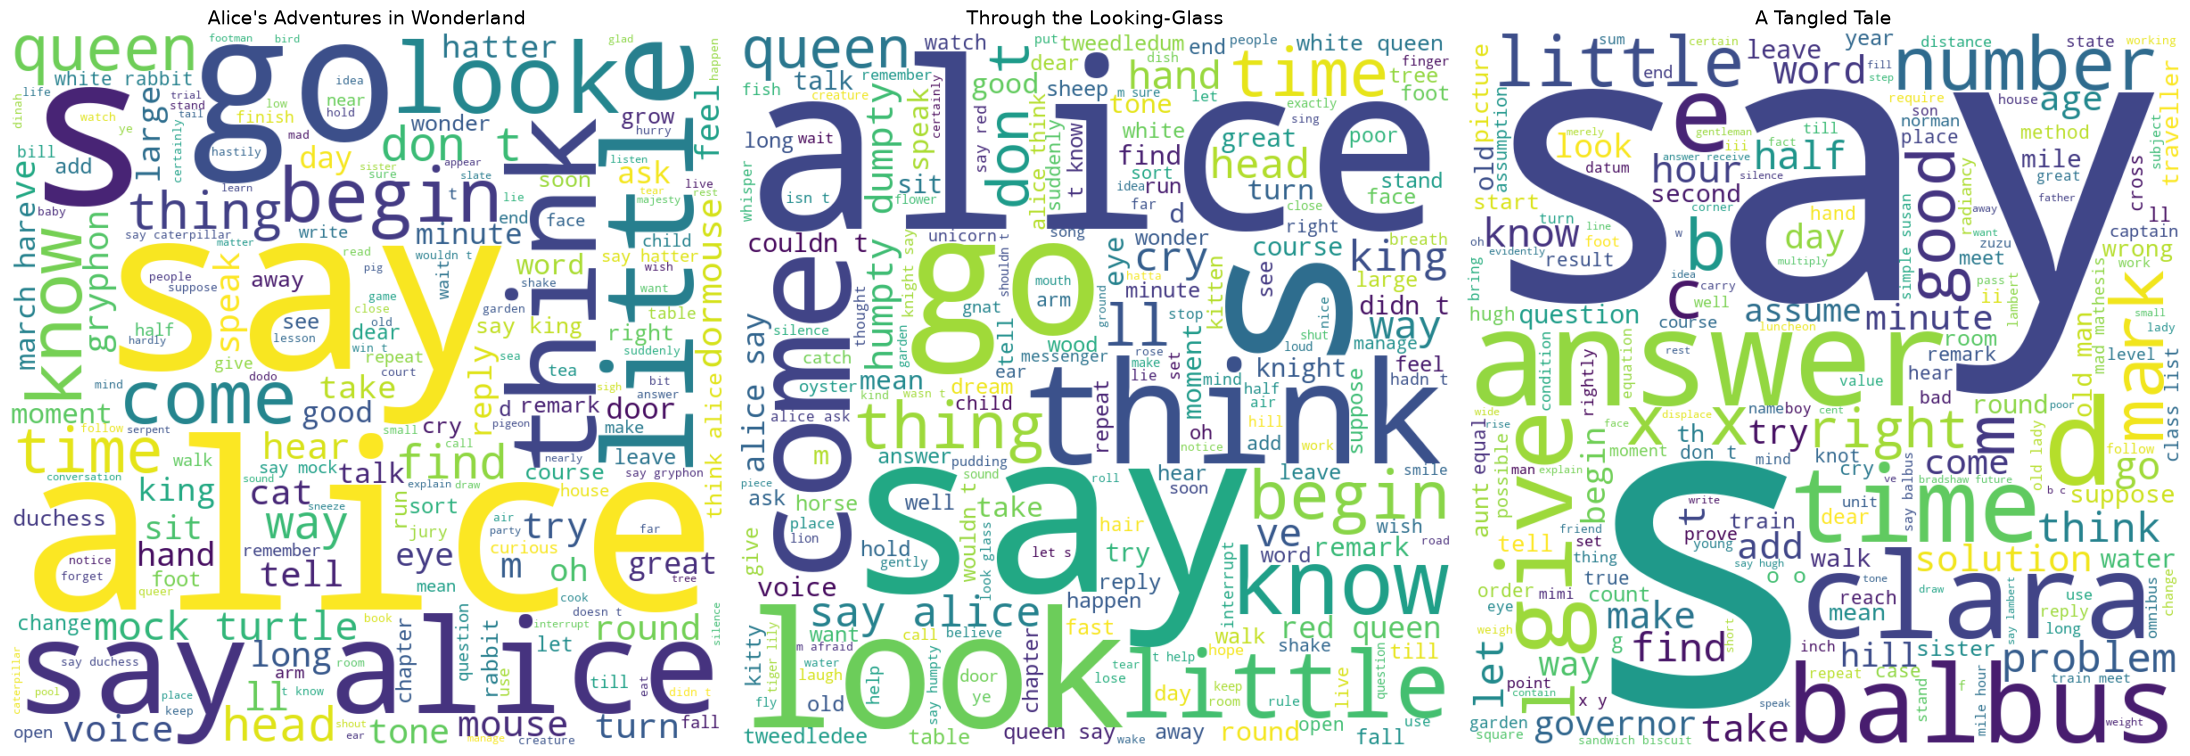

In [12]:
# One row of three subplots, one word cloud per book.
fig, axes = plt.subplots(1, 3, figsize=(22, 8))
for ax, title, text in zip(axes, TITLES, docs):
    # generate() sizes each word by how often it appears in the text.
    wc = WordCloud(width=800, height=800, background_color="white",
                   colormap="viridis", max_words=200).generate(text)
    ax.imshow(wc, interpolation="bilinear")   # draw the cloud image
    ax.set_title(title, fontsize=14)
    ax.axis("off")                            # hide the x/y axes
plt.tight_layout()
plt.show()


### 2. Bag-of-Words — five most frequent words across all books

We use the lemmatized text (cleanest option from the preprocessing step).

In [13]:
# CountVectorizer turns the documents into a word-count matrix (the BoW).
bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(docs)   # shape: (n_docs, n_vocab)

vocab = bow_vectorizer.get_feature_names_out()    # the column -> word mapping
total_counts = bow_matrix.sum(axis=0).A1          # total count of each word (all docs)

# Pair every word with its total count and sort from most to least frequent.
freq = sorted(zip(vocab, total_counts), key=lambda x: x[1], reverse=True)
top5 = freq[:5]                                   # keep the five most frequent

print("Five most frequent words across all three books:")
for word, count in top5:
    print(f"  {word:>8}: {count}")


Five most frequent words across all three books:
       say: 1157
     alice: 870
     think: 305
        go: 302
    little: 295


### 3. Reading the Bag-of-Words matrix

The BoW matrix is stored as a **sparse matrix**. Each stored value is a triple
`(document_index, word_index) -> count`:

* **document number** — which book (row): `0` = Alice, `1` = Looking-Glass, `2` = Tangled Tale
* **word index** — the column, i.e. the position of the word in the vocabulary
  (`bow_vectorizer.get_feature_names_out()[index]`)
* **count** — how many times that word appears in that document

In [14]:
# shape = (number of documents, size of the vocabulary).
print("Matrix shape (documents x vocabulary):", bow_matrix.shape)
print()
print("Raw sparse representation  (doc_index, word_index)  count")
print("---------------------------------------------------------")
# Convert to COO format so we can iterate over its (row, col, value) entries.
coo = bow_matrix.tocoo()
shown = 0
for doc_idx, word_idx, count in zip(coo.row, coo.col, coo.data):
    # doc_idx = which book, word_idx = which vocabulary word, count = how many times.
    print(f"  ({doc_idx}, {word_idx})\t{count}\t-> '{vocab[word_idx]}'")
    shown += 1
    if shown == 10:   # only print the first 10 entries
        break
print("  ... (showing the first 10 non-zero entries)")

# Concrete example: look up the most frequent word in every document.
top_word = top5[0][0]                  # the #1 word from the previous cell
top_idx = list(vocab).index(top_word)  # its column index in the matrix
print()
print(f"Example: the word '{top_word}' is at vocabulary index {top_idx}.")
for doc_idx in range(bow_matrix.shape[0]):
    # bow_matrix[doc_idx, top_idx] = count of that word in that document.
    print(f"  document {doc_idx} ({TITLES[doc_idx]}): {bow_matrix[doc_idx, top_idx]} occurrences")


Matrix shape (documents x vocabulary): (3, 4474)

Raw sparse representation  (doc_index, word_index)  count
---------------------------------------------------------
  (0, 3706)	2	-> 'start'
  (0, 3022)	1	-> 'project'
  (0, 1768)	1	-> 'gutenberg'
  (0, 1233)	1	-> 'ebook'
  (0, 115)	400	-> 'alice'
  (0, 69)	3	-> 'adventures'
  (0, 4406)	4	-> 'wonderland'
  (0, 1959)	1	-> 'illustration'
  (0, 2257)	1	-> 'lewis'
  (0, 564)	1	-> 'carroll'
  ... (showing the first 10 non-zero entries)

Example: the word 'say' is at vocabulary index 3367.
  document 0 (Alice's Adventures in Wonderland): 479 occurrences
  document 1 (Through the Looking-Glass): 490 occurrences
  document 2 (A Tangled Tale): 188 occurrences


### 4. Pie chart of the 5 most frequent words

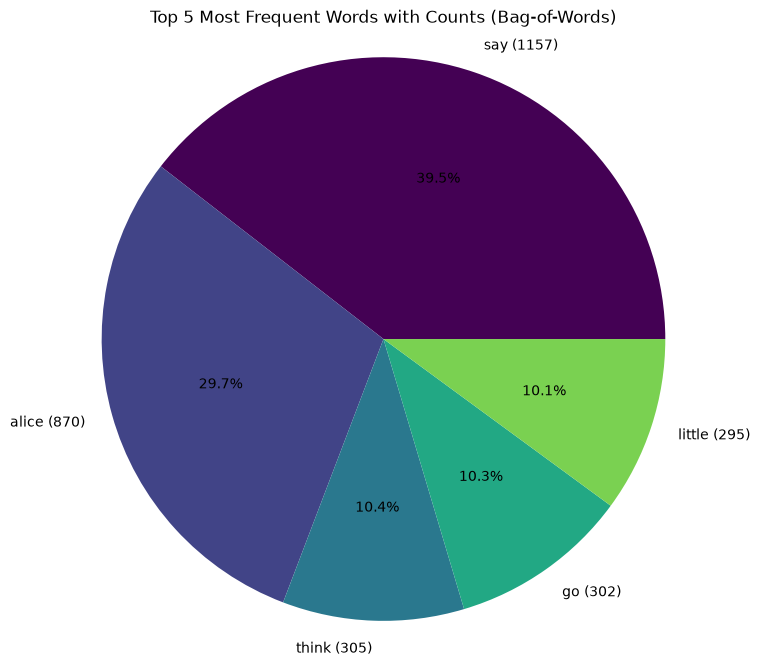

In [15]:
# Build the slice labels ("word (count)") and the slice sizes (the counts).
labels = [f"{w} ({c})" for w, c in top5]
counts = [c for w, c in top5]

plt.figure(figsize=(8, 8))
# autopct shows each slice's percentage; colors give a viridis gradient.
plt.pie(counts, labels=labels, autopct="%1.1f%%",
        colors=plt.cm.viridis([i / len(counts) for i in range(len(counts))]))
plt.title("Top 5 Most Frequent Words with Counts (Bag-of-Words)")
plt.axis("equal")   # keep the pie circular
plt.show()


### 5. Are those words informative?

**No — they are expected, not insightful.** The top words are things like
`alice`, `say`, `little`, `go`, `know`. In books *about Alice*, the word
`alice` is obviously everywhere, and verbs like `say`/`go` are extremely common
in any narrative. Because plain BoW treats every word equally, the most
*frequent* words are simply the most *generic* ones — they tell us almost
nothing that distinguishes one book from another.

This is exactly the weakness that **TF-IDF** fixes below.

## Solving the frequency problem with TF-IDF

TF-IDF (Term Frequency–Inverse Document Frequency) weights a word by how often
it appears in a document **relative to the rest of the corpus**. A word that is
common in one book but rare in the others gets a high score (it is
distinctive), while a word common to every book (`alice`, `say`) is down-weighted.

### 1. Build a BoW with the TF-IDF vectorizer

We pass `min_df=1, max_df=2` because the dataset is tiny (3 documents): with
`max_df=2`, any word appearing in all 3 books is dropped — removing exactly the
generic words that BoW over-rewarded.

In [16]:
# min_df=1: keep words appearing in at least 1 doc.
# max_df=2: drop words appearing in more than 2 of the 3 docs (the generic ones).
tfidf_vectorizer = TfidfVectorizer(min_df=1, max_df=2)
tfidf_matrix = tfidf_vectorizer.fit_transform(docs)        # TF-IDF weight matrix
tfidf_vocab = tfidf_vectorizer.get_feature_names_out()     # column -> word mapping

print("TF-IDF matrix shape (documents x vocabulary):", tfidf_matrix.shape)
print()
for doc_idx, title in enumerate(TITLES):
    row = tfidf_matrix[doc_idx].toarray().ravel()   # this document's TF-IDF scores
    # argsort() sorts ascending; reverse with [::-1] and take the 5 highest scores.
    top_idx = row.argsort()[::-1][:5]
    print(f"=== {title} — top 5 by TF-IDF ===")
    for i in top_idx:
        print(f"  {tfidf_vocab[i]:>12}: {row[i]:.4f}")   # word and its score
    print()


TF-IDF matrix shape (documents x vocabulary): (3, 3766)

=== Alice's Adventures in Wonderland — top 5 by TF-IDF ===
       gryphon: 0.3320
        rabbit: 0.3260
        turtle: 0.2846
          mock: 0.2617
        hatter: 0.2617

=== Through the Looking-Glass — top 5 by TF-IDF ===
        dumpty: 0.3541
        humpty: 0.3541
        knight: 0.2837
    tweedledum: 0.2339
    tweedledee: 0.1834

=== A Tangled Tale — top 5 by TF-IDF ===
        balbus: 0.3261
         clara: 0.2893
       problem: 0.2067
         train: 0.1851
      solution: 0.1745



### 2. Pie charts of the 5 most relevant words per document (TF-IDF)

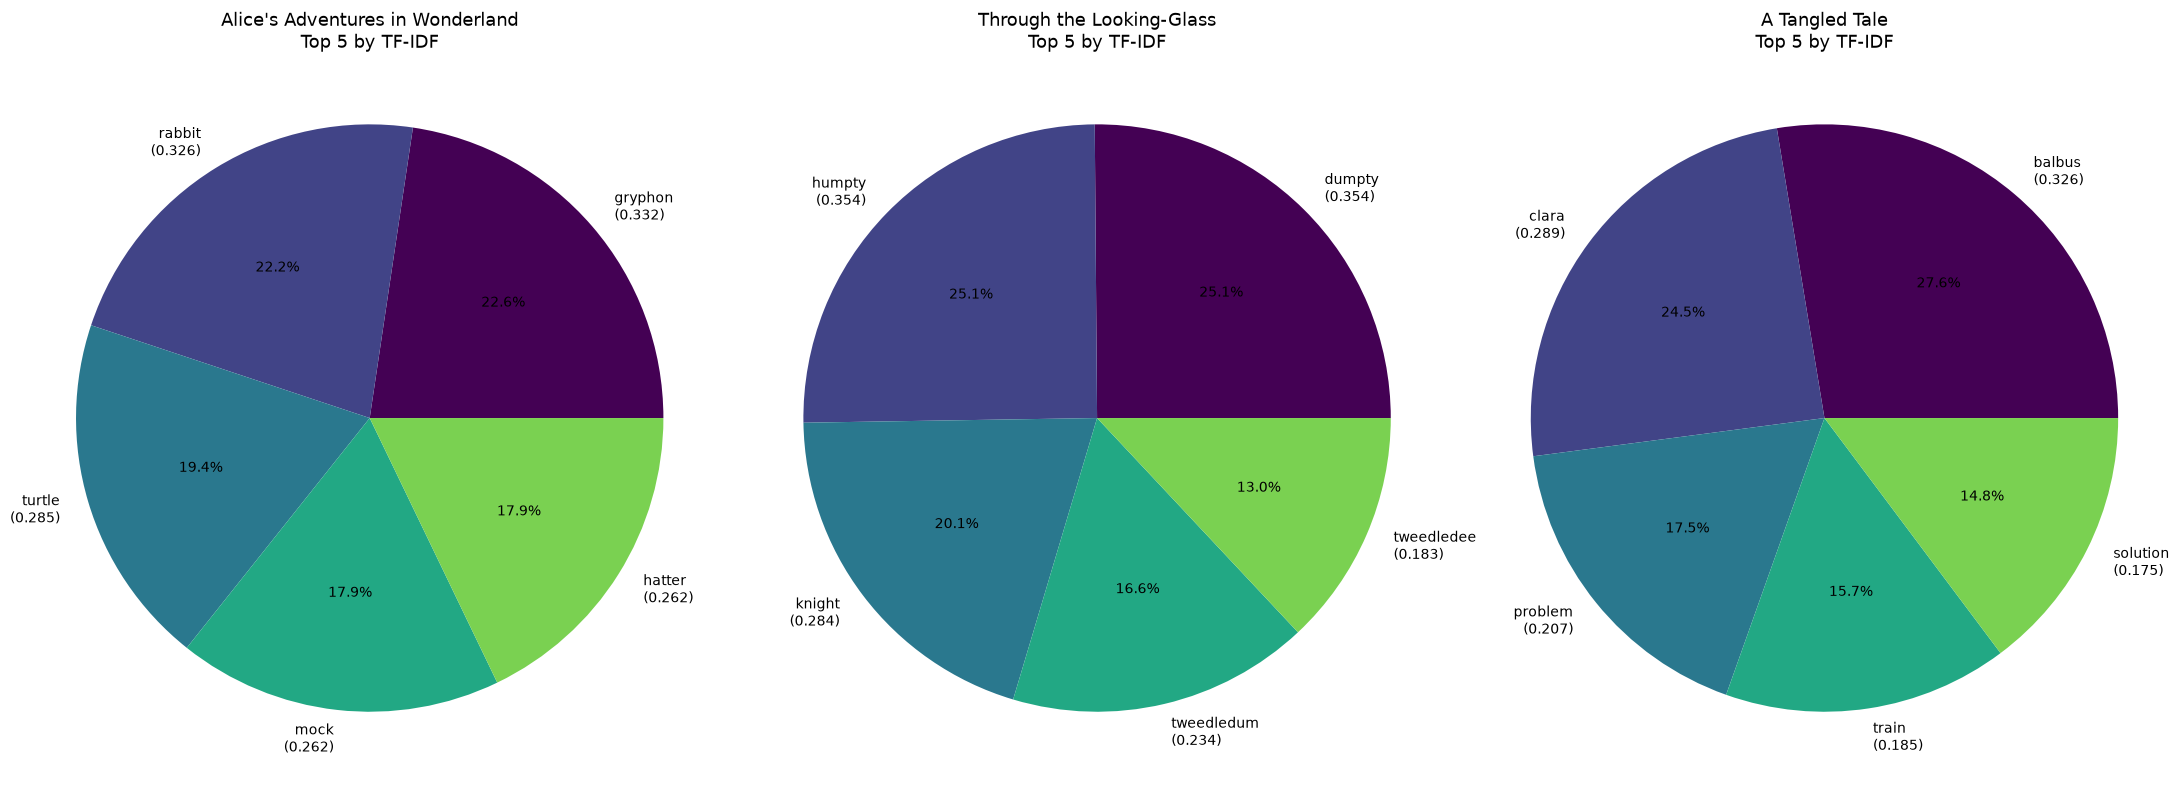

In [17]:
# One pie chart per book, each showing that book's 5 highest-TF-IDF words.
fig, axes = plt.subplots(1, 3, figsize=(22, 8))
for ax, doc_idx, title in zip(axes, range(len(TITLES)), TITLES):
    row = tfidf_matrix[doc_idx].toarray().ravel()   # this document's TF-IDF scores
    top_idx = row.argsort()[::-1][:5]               # indices of the 5 best words
    words = [tfidf_vocab[i] for i in top_idx]       # the words themselves
    scores = [row[i] for i in top_idx]              # their TF-IDF scores
    # Label each slice with the word and its score on a second line.
    labels = [f"{w}\n({s:.3f})" for w, s in zip(words, scores)]
    ax.pie(scores, labels=labels, autopct="%1.1f%%",
           colors=plt.cm.viridis([j / len(scores) for j in range(len(scores))]))
    ax.set_title(f"{title}\nTop 5 by TF-IDF", fontsize=13)
    ax.axis("equal")   # keep each pie circular
plt.tight_layout()
plt.show()


### Conclusion

With TF-IDF the top words become **distinctive** to each book — character names
and themes unique to that story rather than generic verbs. Compared with plain
Bag-of-Words, where every book's top words were dominated by `alice` and `say`,
TF-IDF surfaces what actually makes each text different. This is why TF-IDF is
the preferred weighting for tasks like search, document similarity and
classification.